In [1]:
import sys
import os
os.chdir('/zhome/71/c/146676/main/')
import time
import SimpleITK as sitk
import numpy as np
from astropy.io import fits
from helpers import module_auxiliary as ma
import tifffile
from multiprocessing import Pool
import matplotlib.pyplot as plt
from helpers import extended_data as ed
from cil.recon import FBP
#from cil.plugins.astra import FBP
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.optimisation.functions import L2NormSquared, L1Norm, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares
from cil.optimisation.operators import BlockOperator, GradientOperator, IdentityOperator, FiniteDifferenceOperator
from cil.optimisation.algorithms import CGLS, SIRT, GD, FISTA, ISTA, PDHG, SPDHG
from cil.plugins.astra.operators import ProjectionOperator
from cil.optimisation.functions import IndicatorBox, MixedL21Norm, L2NormSquared, \
                                       BlockFunction, L1Norm, LeastSquares, \
                                       OperatorCompositionFunction, TotalVariation, \
                                       ZeroFunction
from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator
import h5py
from cil.utilities.display import show_geometry
from scipy.ndimage import uniform_filter1d
from cil.processors import Slicer
from scipy.interpolate import interp1d
import cv2
import hdf5plugin

In [2]:

def cartesian_to_polar_opencv(matrix,num_phi=360,num_rad = None):
    rows, cols = matrix.shape
    bias_col = 28
    bias_row = 33
    center = (cols // 2+bias_col, rows // 2+bias_row)  # Define center as origin
    max_radius = (min(cols, rows) // 2)-210
    if num_rad is None:
        num_rad = max_radius
    # Convert Cartesian to Polar using OpenCV's warpPolar
    polar_matrix = cv2.warpPolar(
        matrix, (num_rad, num_phi), center, max_radius,
        cv2.WARP_POLAR_LINEAR + cv2.INTER_LINEAR
    )

    return polar_matrix



def DA_loader(batch_id,q_value=0.75):
    Nx = 362
    with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_non_integrated/scan-0339_pilatus.h5', 'r') as file:
        # Check the keys in the file (this shows the main datasets or groups)
        all_polar3 = []
        all_cartesian = []
        # Access a dataset or group (replace 'your_dataset' with the correct key)
        for i in range(Nx-350):
            dataset_ = file['entry']['instrument']['pilatus']['data'][Nx*batch_id + i+200]  # Replace 'your_dataset' with the actual name of the dataset
            dataset = np.pad(dataset_, 600, mode='constant', constant_values=0)
            dataset[dataset<0] = 0
            polar_matrix = cartesian_to_polar_opencv(dataset.astype(np.float32),num_phi=360, num_rad=2000)
            #q_max = np.quantile(masked_polar ,q_value,axis=0)
            #q_min = np.quantile(masked_polar,0,axis=0)

            polar_matrix_no_zeros = np.where(polar_matrix == 0, np.nan, polar_matrix)

            # Compute quantiles while ignoring NaNs
            polar_matrix_no_zeros[0] = 10000
            q_max = np.nanquantile(polar_matrix_no_zeros, q_value, axis=0)
            polar2 = np.clip(polar_matrix, 0, q_max)
            polar3 = np.sum(polar2,axis=0)

            angles = np.linspace(0.0145, 18.408,2001, endpoint=True)
            r_nonunif = np.sin(np.radians(angles))
            r_nonunif = np.linspace(r_nonunif[0], r_nonunif[-1],2001,endpoint=True)
            r_unif = np.linspace(0,0.310,2030, endpoint=True)
            r_unif = np.delete(r_unif, range(170,200))
            interp_func = interp1d(r_unif, polar3, kind='linear', bounds_error=False, fill_value="extrapolate")
            polar3 = interp_func(r_nonunif)
            polar3_trimmed = polar3.reshape(-1, 3)  # Reshape into (667, 3)
            polar3 = polar3_trimmed.mean(axis=1) 


            all_polar3.append(polar3)
            all_cartesian.append(dataset)
        return np.stack(all_polar3), np.stack(all_cartesian)


batch_ids = range(100,103)  # Generate batch_id values
q_value = 0.6  # Constant q_value

with Pool() as pool:
    results = pool.starmap(DA_loader, [(batch_id, q_value) for batch_id in batch_ids])

polar_list, cart_list = zip(*results)  # Unpack tuples into separate lists
stacked_polar = np.stack(polar_list, axis=0)  # Shape: (2, Nx-300, N)
stacked_cartesian = np.stack(cart_list, axis=0)


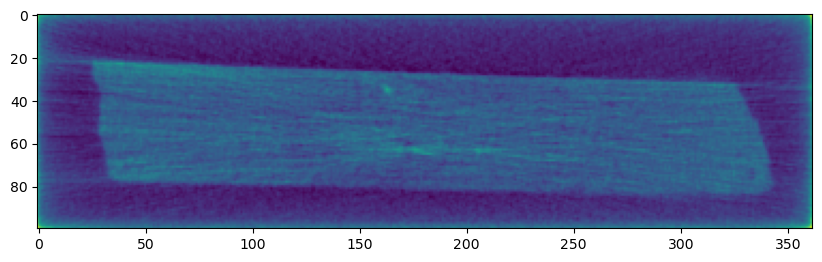

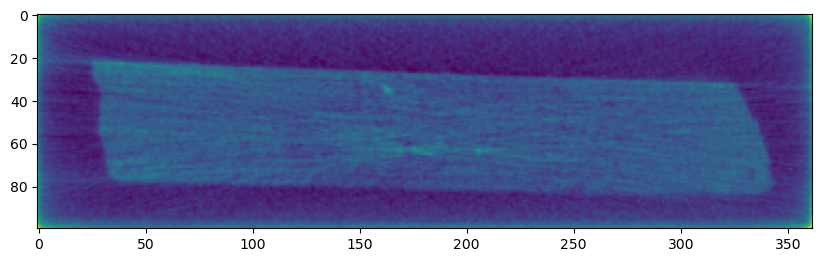

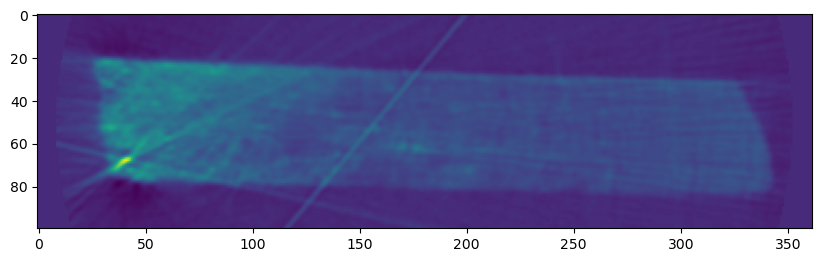

In [20]:
import nibabel as nib

# Load the NIfTI file
img = nib.load("/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/fista_filtered_0_6-0.nii")

# Get the NumPy array
N = 150
recon= img.get_fdata()
plt.figure(figsize=(10,10))
plt.imshow(recon[N])
plt.show()
img = nib.load("/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/fista_filtered_0_6-1.nii")

# Get the NumPy array
recon= img.get_fdata()
plt.figure(figsize=(10,10))
plt.imshow(recon[N])
plt.show()
plt.figure(figsize=(10,10))
plt.imshow(recon_gridrec[3*N])
plt.show()

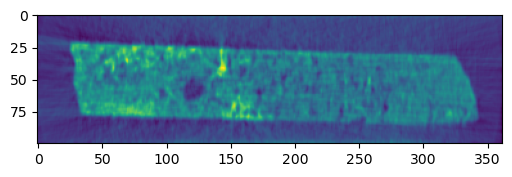

In [58]:
import nibabel as nib

# Load the NIfTI file
img = nib.load("/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/cgls_filtered_0_6-1.nii")
recon1 = img.get_fdata()
plt.close('all')
plt.figure(figsize=(6,10))
plt.imshow(recon1[N])

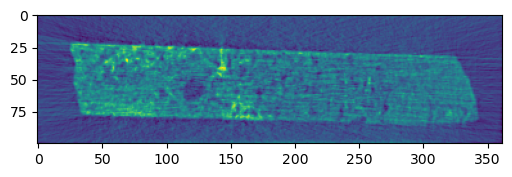

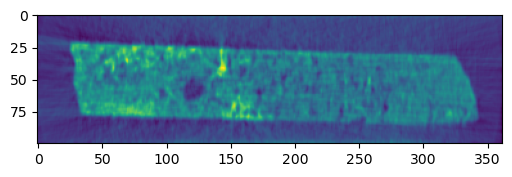

In [ ]:
import nibabel as nib

# Load the NIfTI file
img = nib.load("/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/cgls_filtered_0_6.nii")
recon2 = img.get_fdata()
plt.close('all')
plt.figure(figsize=(10,10))
plt.imshow(recon2[N])

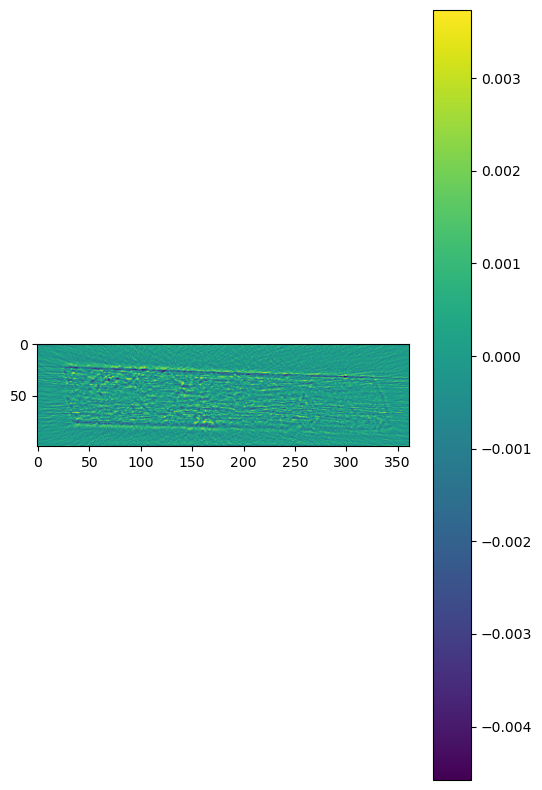

In [60]:
plt.close('all')
plt.figure(figsize=(6,10))
plt.imshow(recon1[N]-recon2[N])
plt.colorbar()

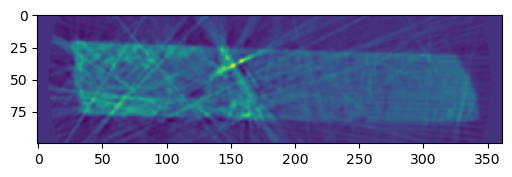

In [30]:
recon = img.get_fdata()
plt.close('all')
plt.figure(figsize=(6,10))
plt.imshow(recon_gridrec[N])

In [3]:
c0 = 0
c1 = 2000
print((c1-c0)/3)

y0 = 130
y1 = 230

pad = 150

666.6666666666666


In [4]:

def zero_pad_3d(array: np.ndarray, N: int, values: np.ndarray) -> np.ndarray:
    """
    Pads a 3D NumPy array along the last two dimensions by N pixels.
    Each slice along axis=0 is padded with a different value.

    Parameters:
    array (np.ndarray): Input 3D array of shape (D, H, W).
    N (int): Number of pixels to pad along the last two dimensions.
    values (np.ndarray): 1D array of length D, specifying the padding value for each slice.

    Returns:
    np.ndarray: Padded 3D array of shape (D, H+2N, W+2N).
    """
    if N < 0:
        raise ValueError("Padding size N must be non-negative")
    
    if values.shape[0] != array.shape[0]:
        raise ValueError("Length of values array must match the first dimension of array")

    D, H, W = array.shape
    padded_shape = (D, H, W + 2 * N)
    padded_array = np.empty(padded_shape, dtype=array.dtype) 

    # Apply different padding values per slice
    for i in range(D):
        padded_array[i] = np.pad(
            array[i], 
            ((0, 0), (N, N)), 
            mode='constant', 
            constant_values=values[i]
        )

    return padded_array

In [5]:
# Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_ct_integrated/scan-0339_pilatus_integrated.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dataset = file['entry']['data1d']['I'][:][:,c0:c1]  # Replace 'your_dataset' with the actual name of the dataset
    dataset  = dataset.reshape(181, 362, c1-c0).transpose([2,0,1])
    two_theta = file['entry']['data1d']['2th'][:]

# Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_reconstructions/scan-339_recon.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    recon_gridrec = (file['reconstructed']['gridrec'][:]/5000).transpose([2,0,1])[c0:c1,y0:y1]
     # Replace 'your_dataset' with the actual name of the dataset
     
    # Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_attenuation/scan-0339_xspress3-dtc-2d.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_all_events = dtc['all_events'][:].reshape(181,362)
    data_output_count_rate = dtc['output_count_rate'][:].reshape(181,362)
    data_att = dtc['window_counts'][:][:,0].reshape(181,362)



In [6]:

dataset2 = np.load('/dtu-compute/msaca/sliceA_diffraction/xrd_non_integrated/filtered_integrations/median_clipped_0_6.npy')
dataset = np.transpose(dataset2/200,[2,0,1])[:][c0//3:c1//3]

In [7]:
print(np.shape(dataset))

(666, 181, 362)


In [8]:
shifts = np.int32(np.linspace(0,18,(c1-c0)//3,endpoint=True))
data_att_mod = -np.log(np.clip(data_att,a_min=0,a_max=7000)/7000)
C = np.array([np.concatenate((data_att_mod[i:, :], data_att_mod[:i, :]), axis=0) for i in shifts])
mm = np.mean(C,axis=2)

In [9]:
scale_factors = np.arange(667).reshape(-1, 1) / 667 # Shape: (2000, 1)
scale_factors = scale_factors[c0//3:c1//3]
print(c0)
print(c1)
print(np.shape(scale_factors))
# Compute the weights with broadcasting
weights_list = []
weights = 1 + 0 * scale_factors * (mm[0] - 0.1)  # Shape: (2000, 100)
weights_list.append(weights)
data = (1e3*dataset/data_att/weights[:,:,np.newaxis]).astype(np.float32)
data_= zero_pad_3d(data, pad,values=np.mean(data[:,:,-10:],axis=(1,2)))
nchannels,ntheta, nx = np.shape(data)
nchannels,ntheta, nx_ = np.shape(data_)
recon_nolog = np.zeros((nchannels, y1-y0, nx))
angles = range(0,ntheta)

ag = AcquisitionGeometry.create_Parallel3D(detector_position=[0,nx_//2,0])\
                            .set_angles(angles)\
                            .set_panel((nx_, nchannels), pixel_size=(1,1))\
                            .set_labels(['vertical','angle', 'horizontal'])
data_ = AcquisitionData(data_, geometry=ag)
data_.reorder('astra')
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()
device = 'gpu'


data_cil = AcquisitionData(data_, geometry=ag)
data_cil.reorder('tigre')
fbp = FBP(data_cil, image_geometry=ig,filter='hann')
out = fbp.run()

recon = []
recon.append(out.as_array())


0
2000
(666, 1)
FBP recon

Input Data:
	angle: 181
	vertical: 666
	horizontal: 662

Reconstruction Volume:
	vertical: 666
	horizontal_y: 100
	horizontal_x: 362

Reconstruction Options:
	Backend: tigre
	Filter: hann
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



In [10]:
scale_factors = np.arange(667).reshape(-1, 1) / 667 # Shape: (2000, 1)
scale_factors = scale_factors[c0//3:c1//3]
# Compute the weights with broadcasting
weights = 1 + 10 * scale_factors * np.abs((mm[0] - 0.1))  # Shape: (2000, 100)
weights_list.append(weights)
data = (1e3*dataset/data_att/weights[:,:,np.newaxis]).astype(np.float32)
data_= zero_pad_3d(data, pad,values=np.mean(data[:,:,-10:],axis=(1,2)))

nchannels,ntheta, nx = np.shape(data)
nchannels,ntheta, nx_ = np.shape(data_)
recon_nolog = np.zeros((nchannels, y1-y0, nx))
angles = range(0,ntheta)

ag = AcquisitionGeometry.create_Parallel3D(detector_position=[0,nx_//2,0])\
                            .set_angles(angles)\
                            .set_panel((nx_, nchannels), pixel_size=(1,1))\
                            .set_labels(['vertical','angle', 'horizontal'])
data_ = AcquisitionData(data_, geometry=ag)
data_.reorder('astra')
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()
device = 'gpu'


data_cil = AcquisitionData(data_, geometry=ag)
data_cil.reorder('tigre')
fbp = FBP(data_cil, image_geometry=ig,filter='hann')
out = fbp.run()
recon.append(out.as_array())


FBP recon

Input Data:
	angle: 181
	vertical: 666
	horizontal: 662

Reconstruction Volume:
	vertical: 666
	horizontal_y: 100
	horizontal_x: 362

Reconstruction Options:
	Backend: tigre
	Filter: hann
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



In [11]:
scale_factors = np.arange(667).reshape(-1, 1) / 667 # Shape: (2000, 1)
scale_factors = scale_factors[c0//3:c1//3]
# Compute the weights with broadcasting
weights = 1 + 50 * scale_factors * np.maximum(mm[0] - 0.15,0)  # Shape: (2000, 100)
weights_list.append(weights)
data = (1e3*dataset/data_att/weights[:,:,np.newaxis]).astype(np.float32)
data_= zero_pad_3d(data, pad,values=np.mean(data[:,:,-10:],axis=(1,2)))

nchannels,ntheta, nx = np.shape(data)
nchannels,ntheta, nx_ = np.shape(data_)
recon_nolog = np.zeros((nchannels, y1-y0, nx))
angles = range(0,ntheta)

ag = AcquisitionGeometry.create_Parallel3D(detector_position=[0,nx_//2,0])\
                            .set_angles(angles)\
                            .set_panel((nx_, nchannels), pixel_size=(1,1))\
                            .set_labels(['vertical','angle', 'horizontal'])
data_ = AcquisitionData(data_, geometry=ag)
data_.reorder('astra')
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()
device = 'gpu'


data_cil = AcquisitionData(data_, geometry=ag)
data_cil.reorder('tigre')
fbp = FBP(data_cil, image_geometry=ig, filter='hann')
out = fbp.run()
recon.append(out.as_array())
recon.append(recon_gridrec)


FBP recon

Input Data:
	angle: 181
	vertical: 666
	horizontal: 662

Reconstruction Volume:
	vertical: 666
	horizontal_y: 100
	horizontal_x: 362

Reconstruction Options:
	Backend: tigre
	Filter: hann
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for j in range(3):
    ax = axes[j]
    ax.plot(weights_list[j][6])  # Display the i-th image from array j

plt.tight_layout()
plt.show()

In [78]:
for i in np.arange(0,7,2):
    # Create a figure with multiple subplots
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))

    for j in range(4):
        ax = axes[j]
        if j==3:
            i = 3*i
        mean_value = np.mean(recon[j][i])*1000
        ax.imshow(recon[j][i], cmap='gray')#, vmin=-0.01,vmax=0.035)  # Display the i-th image from array j
        ax.axis('off')  # Hide axes
        # Overlay the mean value as text in the top-left corner
        ax.text(
            2, 2, f"Mean: {mean_value:.2f}", color='red', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )

    plt.tight_layout()
    plt.show()

In [60]:
ag = AcquisitionGeometry.create_Parallel2D(detector_position=[0,nx_//2])\
                            .set_angles(angles)\
                            .set_channels(nchannels)\
                            .set_panel((nx_), pixel_size=(1))\
                            .set_labels(['channel','angle', 'horizontal'])
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()




scale_factors = np.arange((c1-c0)//3).reshape(-1, 1) / 667  # Shape: (2000, 1)
weights_list = []
# Compute the weights with broadcasting
weights = 1 + 0 * scale_factors * np.abs((mm[0] - 0.1))  # Shape: (2000, 100)
weights_list.append(weights)
weights = 1 + 10 * scale_factors * np.abs((mm[0] - 0.1))  # Shape: (2000, 100)
weights_list.append(weights)
weights = 1 + 10 * scale_factors * np.abs((mm[0] - 0.15))  # Shape: (2000, 100)
weights_list.append(weights)
recon_cgls = []

for j in range(1):
    weights = weights_list[2]
    data = (1e3*dataset/data_att/weights[:,:,np.newaxis]).astype(np.float32)
    data_= zero_pad_3d(data, pad,values=np.mean(data[:,:,-10:],axis=(1,2)))
    data_ = AcquisitionData(data_, geometry=ag)
    data_.reorder('astra')

    fdx = FiniteDifferenceOperator(ig, direction='horizontal_x', bnd_cond='Neumann')
    fdy = FiniteDifferenceOperator(ig, direction='horizontal_y', bnd_cond='Neumann')
    fdc = FiniteDifferenceOperator(ig, direction='channel', bnd_cond='Neumann')


    # Construct the BlockOperator combining the two operators
    alpha_dc_array = np.array([200])
    for i in range(len(alpha_dc_array)):
        factor = 0.05
        alpha_id = 400*factor
        alpha_dx = 100*factor
        alpha_dy = 100*factor
        alpha_dc = alpha_dc_array[i]*factor
        L = alpha_id*IdentityOperator(ig)
        A = ProjectionOperator(ig, ag, 'gpu')
        FD = BlockOperator(alpha_dx * fdx,alpha_dy *  fdy,alpha_dc *  fdc)
        A_block = BlockOperator(L,FD, A)


        g_block = BlockDataContainer(L.range.allocate(0), FD.range.allocate(0), data_)

        # set up and run CGLS
        optimizer = CGLS(operator=A_block, data=g_block, update_objective_interval=2)
        optimizer.run(15, verbose=1)
        recon_cgls.append(optimizer.solution.as_array().astype(np.float32))

recon_cgls.append(recon_gridrec)

  0%|          | 0/15 [00:00<?, ?it/s]

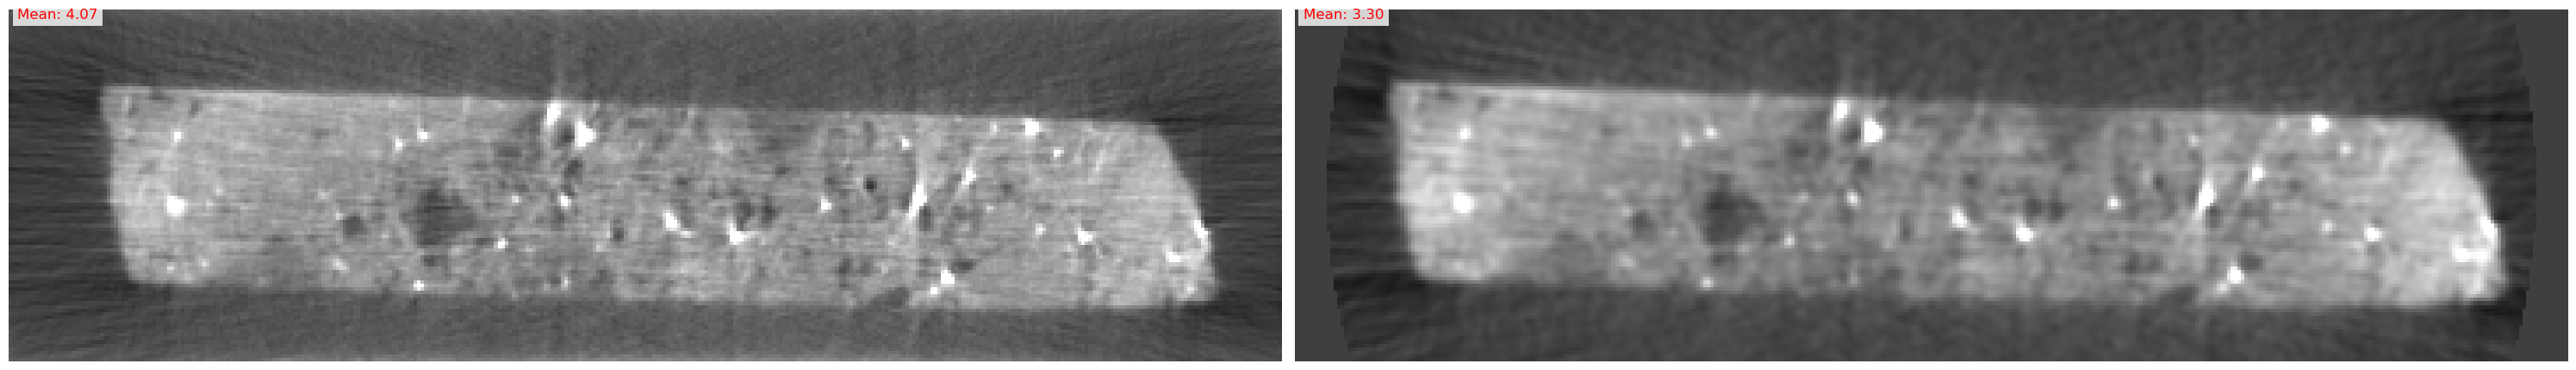

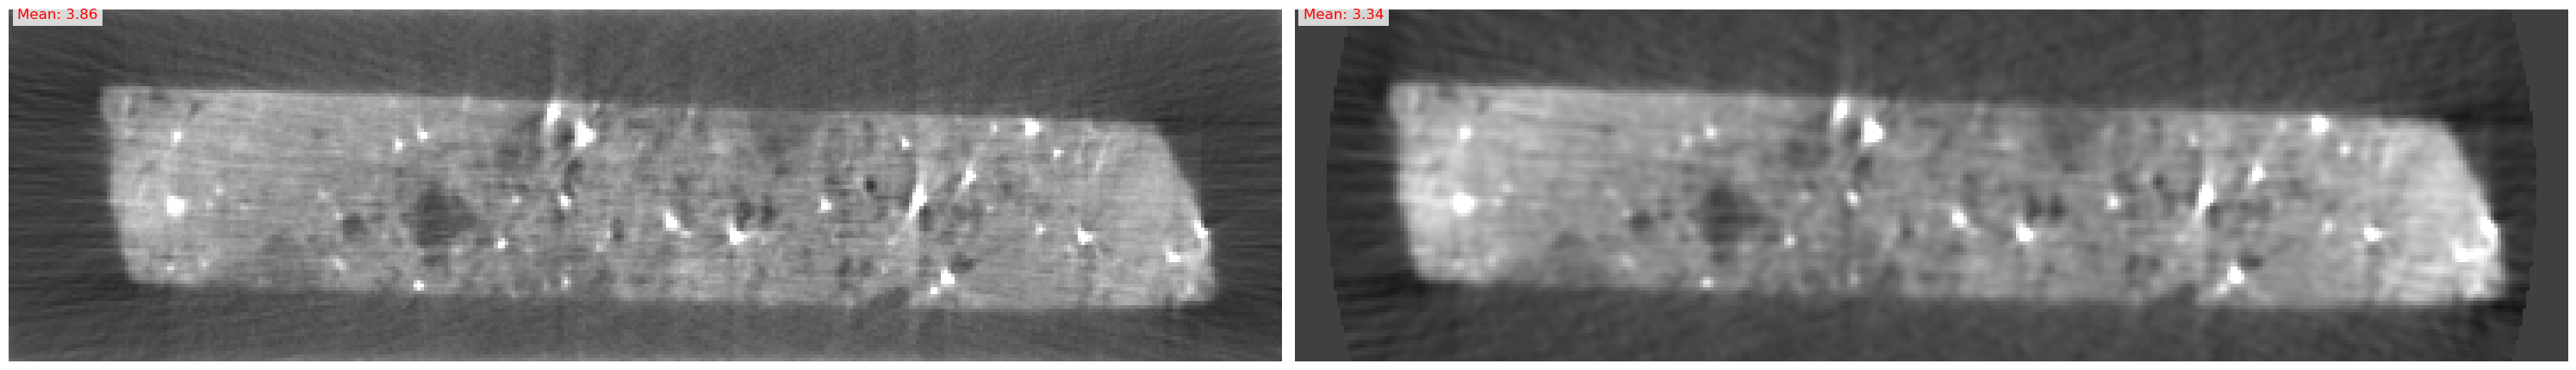

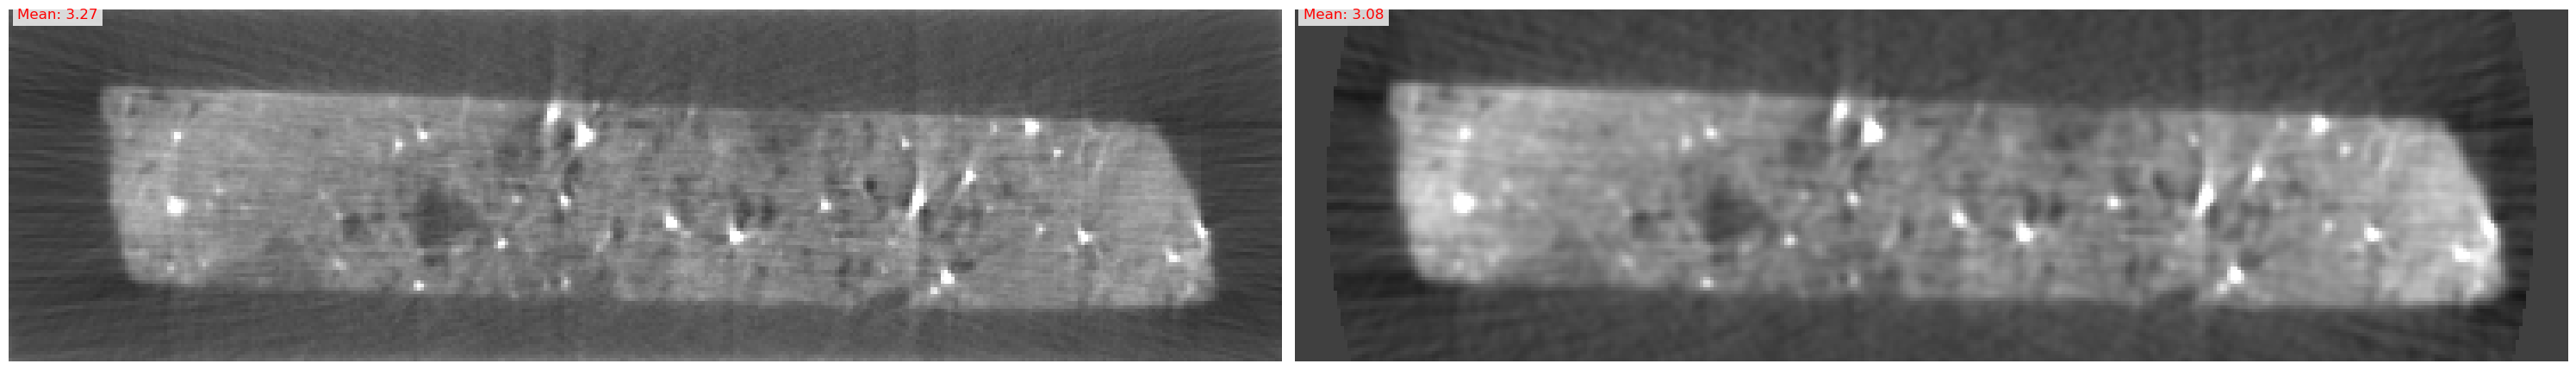

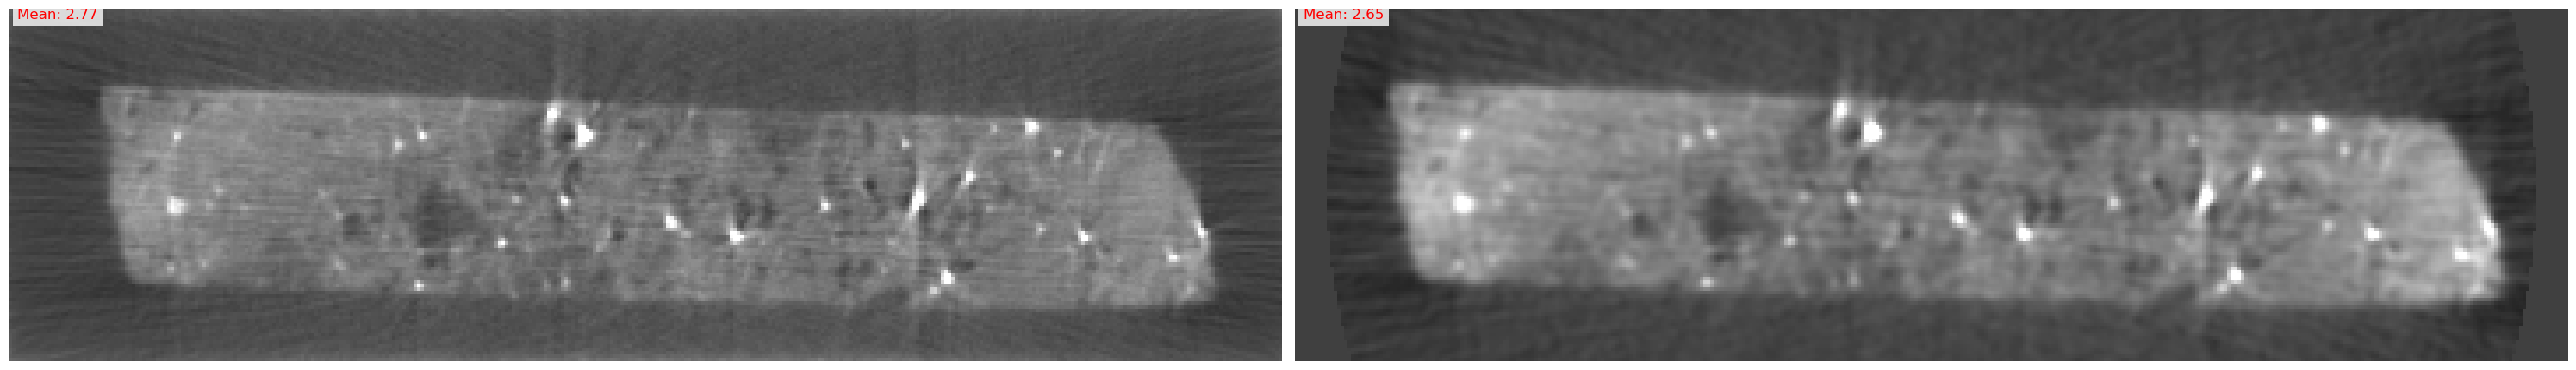

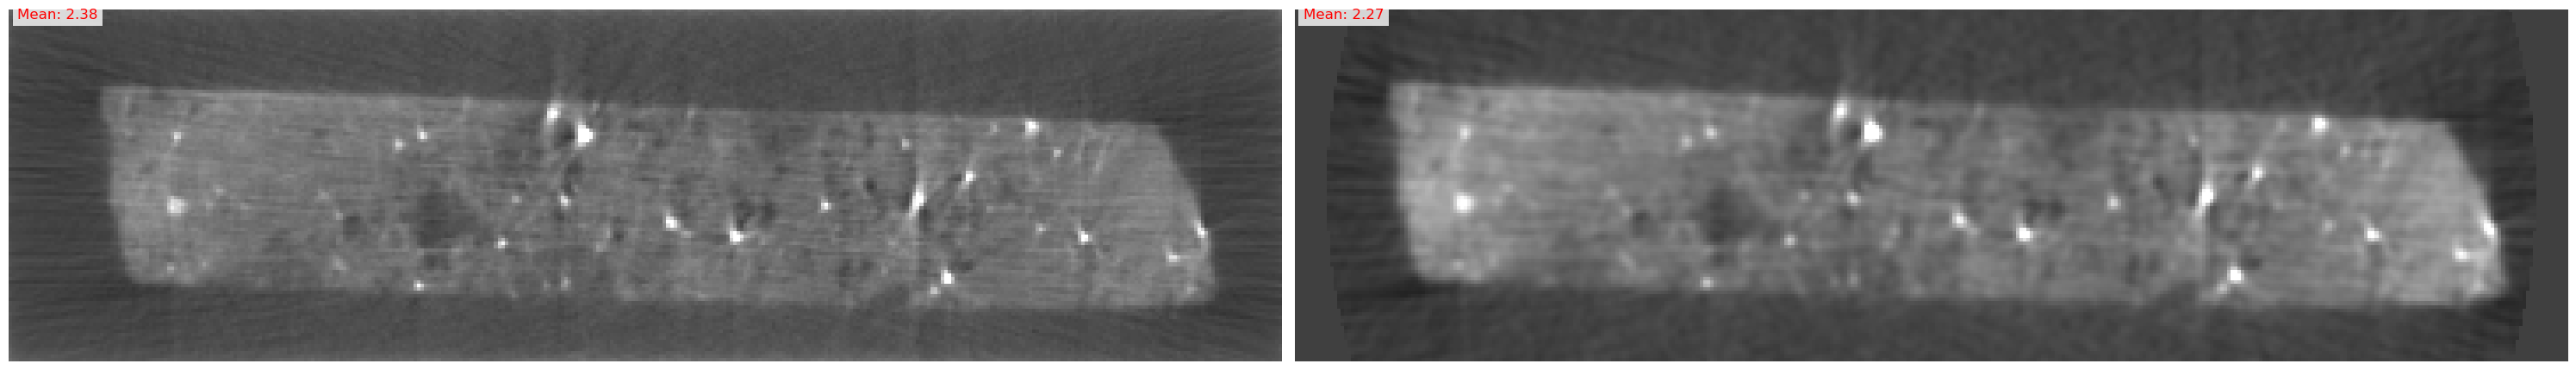

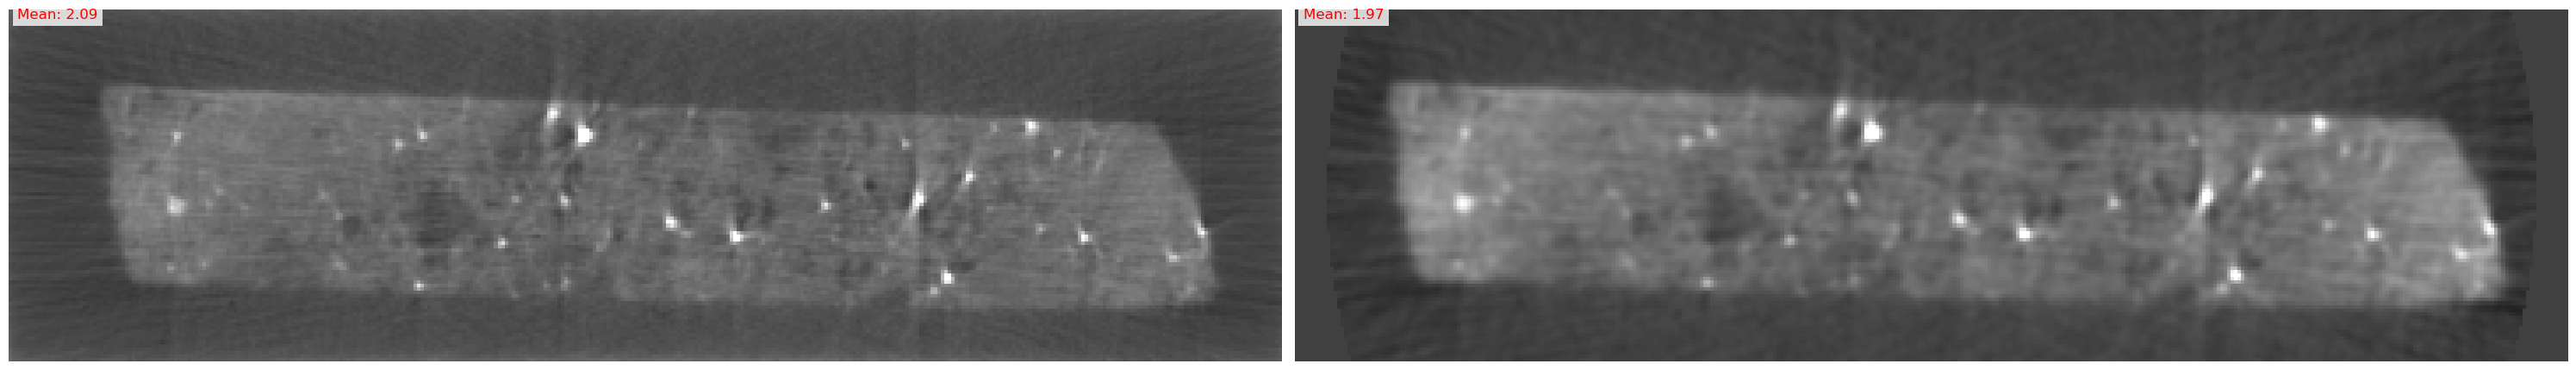

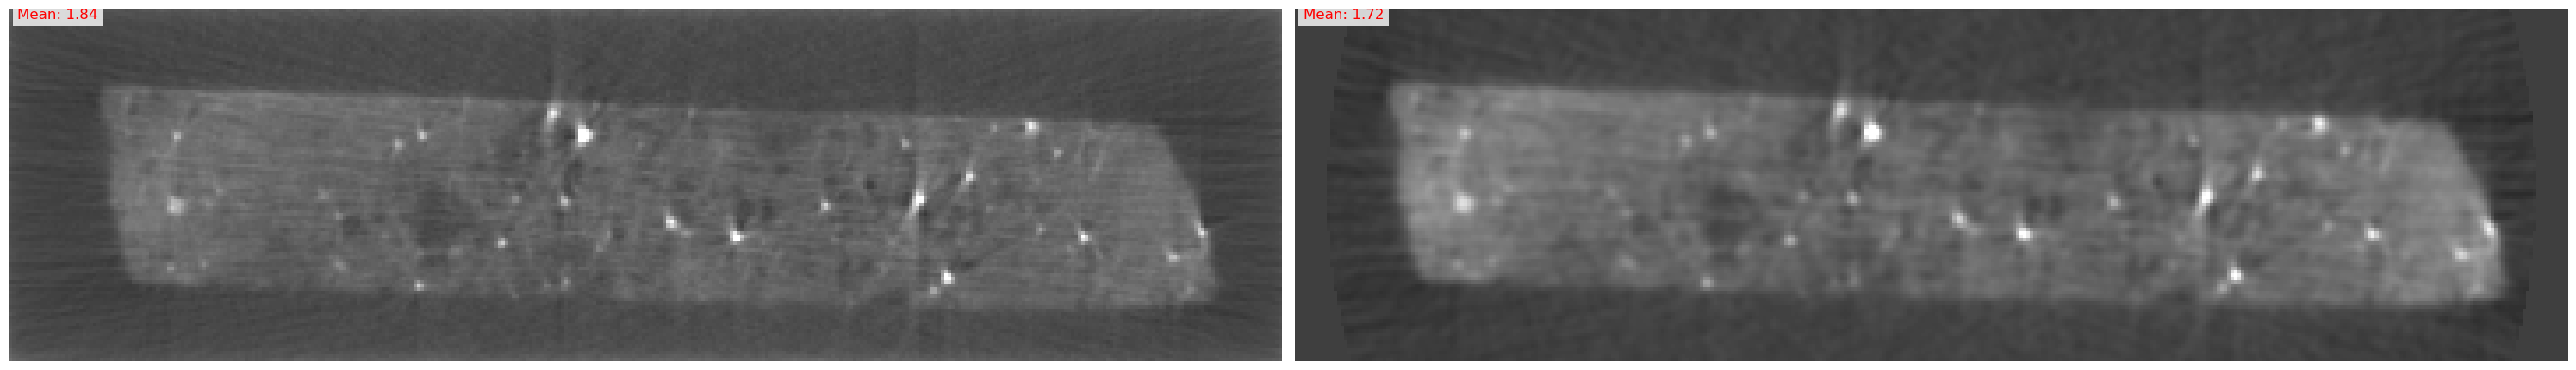

In [61]:
for i in np.arange(0,(c1-c0)//3,(c1-c0)//3//6):
    # Create a figure with multiple subplots
    fig, axes = plt.subplots(1, 2, figsize=(30, 10))

    for j in range(2):
        ax = axes[j]
        if j==1:
            i = 3*i
        mean_value = np.mean(recon_cgls[j][i])*1000
        ax.imshow(recon_cgls[j][i], cmap='gray', vmin=-0.005,vmax=0.015)  # Display the i-th image from array j
        ax.axis('off')  # Hide axes
        # Overlay the mean value as text in the top-left corner
        ax.text(
            2, 2, f"Mean: {mean_value:.2f}", color='red', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )

    plt.tight_layout()
    plt.show()

IndexError: index 200 is out of bounds for axis 0 with size 7

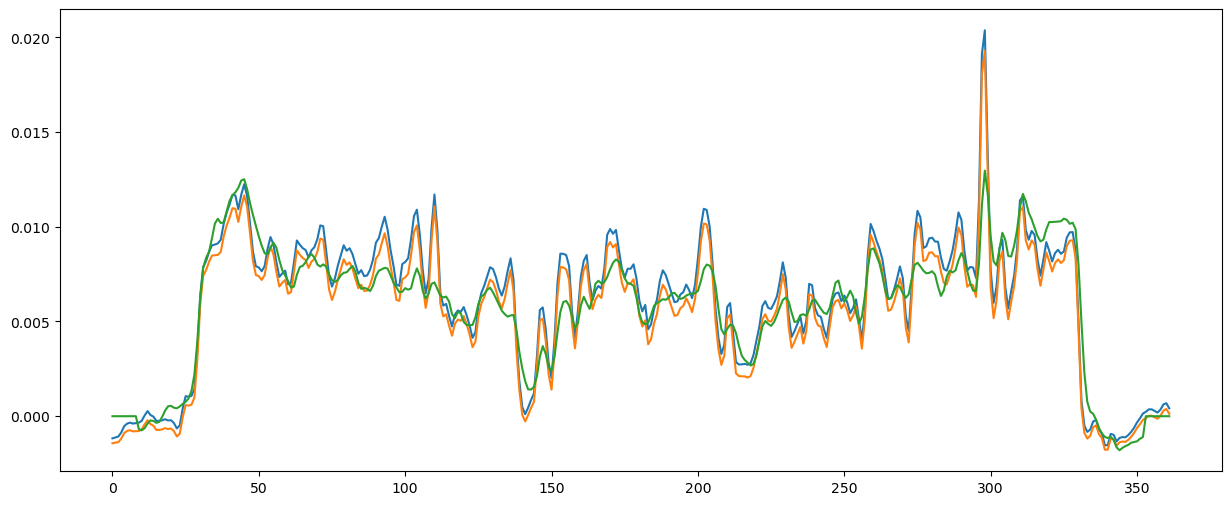

In [62]:
plt.figure(figsize=(15,6))
plt.plot(recon[0][0,40,:])
plt.plot(recon[2][0,40,:])
plt.plot(recon[3][3*0,40,:])
plt.plot(recon_cgls[0][200,40,:])
plt.legend(('FBP1', 'FBP2','Gridrec', 'CGLS'))
plt.show()

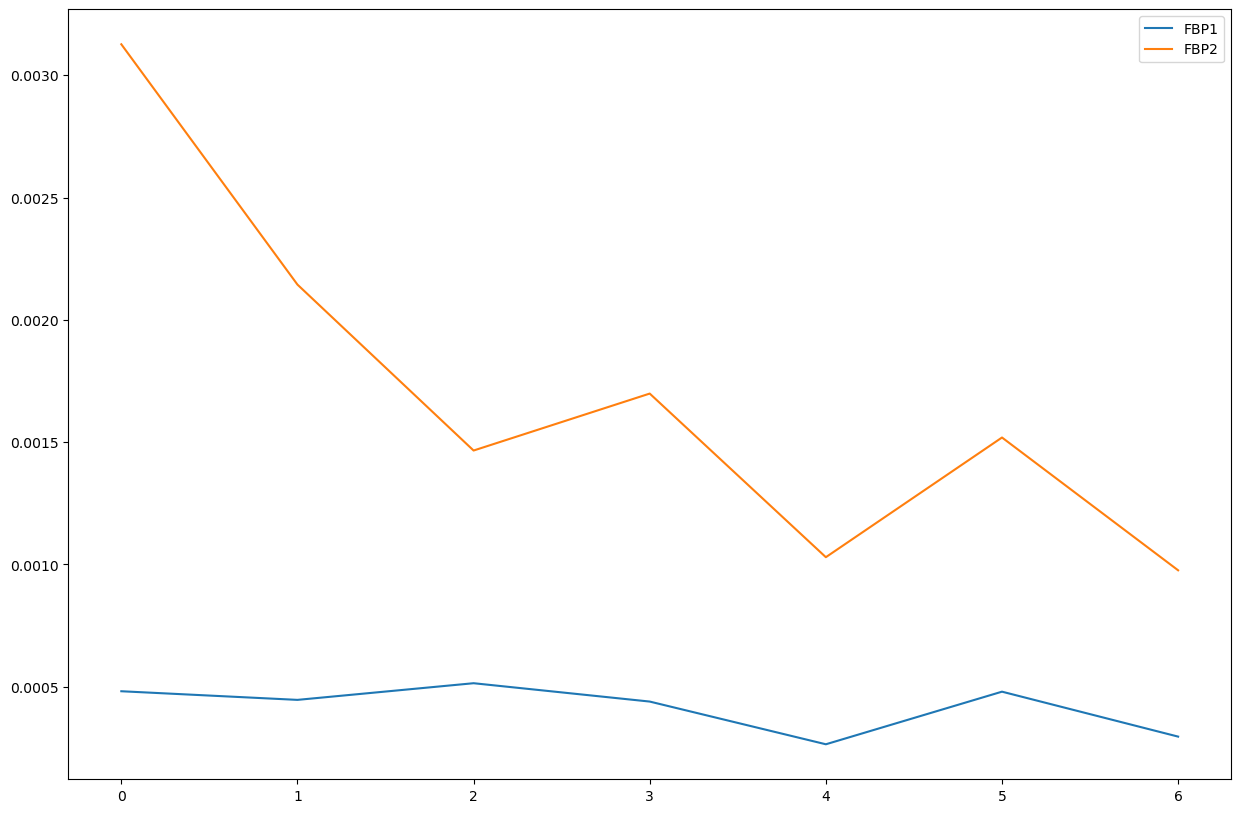

In [63]:
plt.figure(figsize=(15,10))
#plt.plot(recon[0][:,40,150])
#plt.plot(recon[2][:,40,150])
plt.plot(recon[3][::3,40,150]*0.2)
plt.plot(recon_cgls[0][:,40,150])
plt.legend(('FBP1', 'FBP2','Gridrec', 'CGLS'))
plt.show()

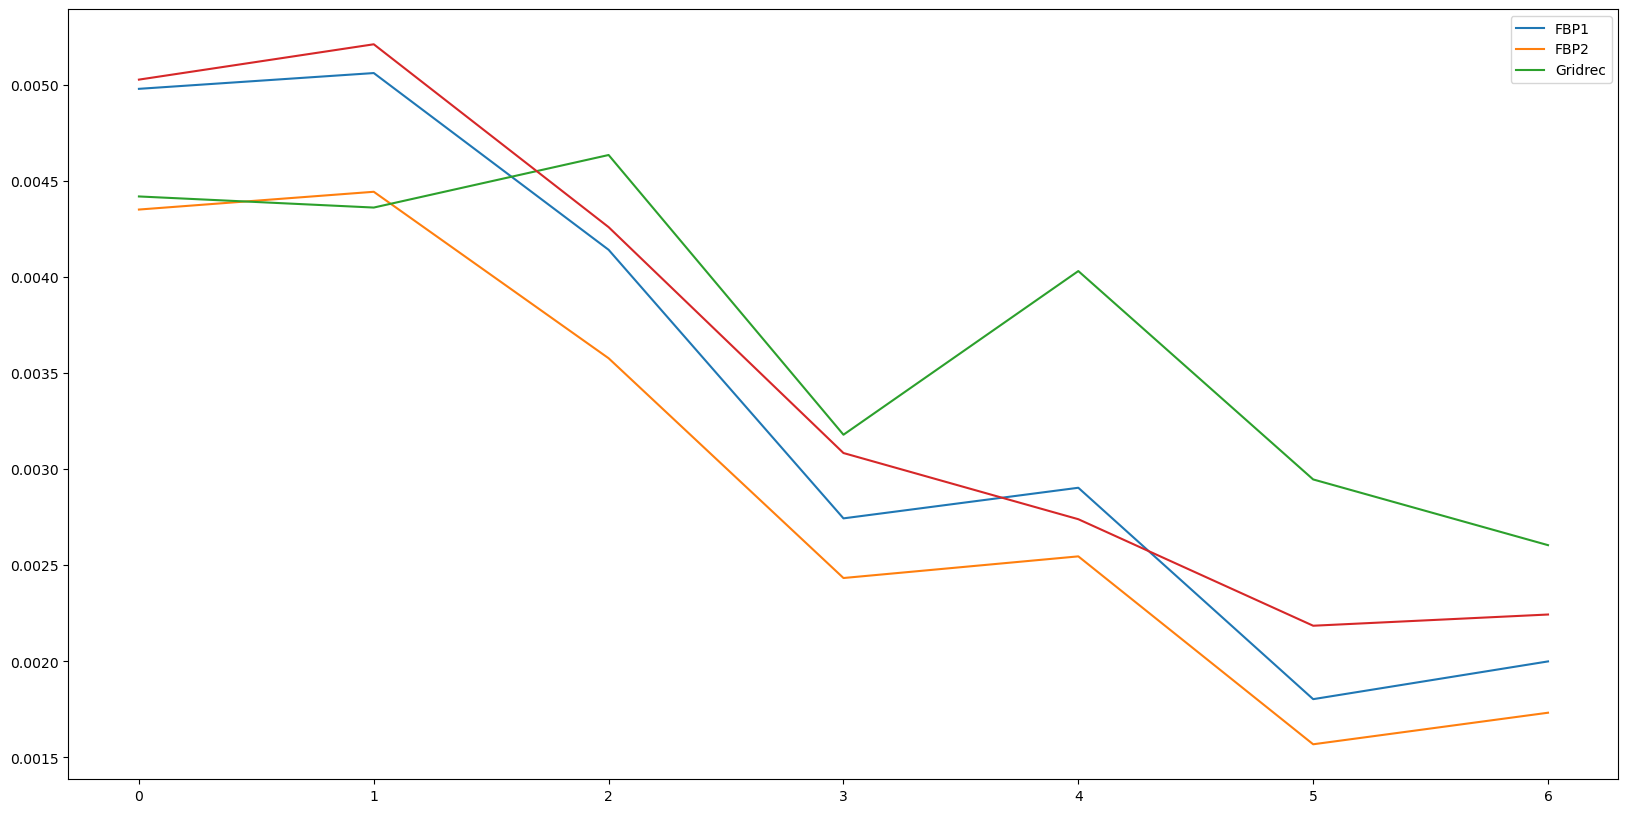

In [64]:
plt.figure(figsize=(20,10))
plt.plot(recon[0][:,50,200])
plt.plot(recon[2][:,50,200])
plt.plot(recon[3][::3,50,200])
plt.legend(('FBP1', 'FBP2','Gridrec', 'CGLS'))
plt.plot(recon_cgls[0][:,50,200])
plt.show()

In [57]:
import nibabel as nib
affine = np.eye(4)
nii_img = nib.Nifti1Image(recon_cgls[0], affine)
nib.save(nii_img, '/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/cgls_filtered_0_6-1.nii')


In [ ]:
ag = AcquisitionGeometry.create_Parallel2D(detector_position=[0,nx_//2])\
                            .set_angles(angles)\
                            .set_channels(nchannels)\
                            .set_panel((nx_), pixel_size=(1))\
                            .set_labels(['channel','angle', 'horizontal'])
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()        
x0 = ig.allocate(0.0)



scale_factors = np.arange((c1-c0)//3).reshape(-1, 1) / 667  # Shape: (2000, 1)
weights_list = []
# Compute the weights with broadcasting
weights = 1 + 0 * scale_factors * np.abs((mm[0] - 0.1))  # Shape: (2000, 100)
weights_list.append(weights)
weights = 1 + 10 * scale_factors * np.abs((mm[0] - 0.1))  # Shape: (2000, 100)
weights_list.append(weights)
weights = 1 + 20 * scale_factors * np.abs((mm[0] - 0.15))  # Shape: (2000, 100)
weights_list.append(weights)

N_iter = [40]

for j in range(1):
    weights = weights_list[2]
    data = (1e3*dataset/data_att/weights[:,:,np.newaxis]).astype(np.float32)
    data_= zero_pad_3d(data, pad,values=np.mean(data[:,:,-10:],axis=(1,2)))
    data_ = AcquisitionData(data_, geometry=ag)
    data_.reorder('astra')

    fdx = FiniteDifferenceOperator(ig, direction='horizontal_x', bnd_cond='Neumann')
    fdy = FiniteDifferenceOperator(ig, direction='horizontal_y', bnd_cond='Neumann')
    fdc = FiniteDifferenceOperator(ig, direction='channel', bnd_cond='Neumann')


    # Construct the BlockOperator combining the two operators
    alpha_dc_array = np.array([200])
    for i in range(len(alpha_dc_array)):
        factor = 0.05
        alpha_id = 400*factor
        alpha_dx = 100*factor
        alpha_dy = 100*factor
        alpha_dc = alpha_dc_array[i]*factor
        L = alpha_id*IdentityOperator(ig)
        A = ProjectionOperator(ig, ag, 'gpu')
        FD = BlockOperator(alpha_dx * fdx,alpha_dy *  fdy,alpha_dc *  fdc)
        A_block = BlockOperator(L,FD, A)


        g_block = BlockDataContainer(L.range.allocate(0), FD.range.allocate(0), data_)

        F = LeastSquares(A_block, g_block)
        G = IndicatorBox(lower=0.0)

        # set up and run CGLS
        optimizer = FISTA(f=F, 
                  g=G, 
                  initial=x0, 
                  update_objective_interval = 10)

        optimizer.run(N_iter[j], verbose=1)
        recon_cgls.append(optimizer.solution.as_array().astype(np.float32))


  0%|          | 0/40 [00:00<?, ?it/s]

NameError: name 'recon_cgls' is not defined

In [13]:
recon_cgls = []
recon_cgls.append(optimizer.solution.as_array().astype(np.float32))

In [14]:
import nibabel as nib
affine = np.eye(4)
nii_img = nib.Nifti1Image(recon_cgls[-1], affine)
nib.save(nii_img, '/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/fista_filtered_0_6-1.nii')

In [58]:
ag = AcquisitionGeometry.create_Parallel2D(detector_position=[0,nx_//2])\
                            .set_angles(angles)\
                            .set_channels(nchannels)\
                            .set_panel((nx_), pixel_size=(1))\
                            .set_labels(['channel','angle', 'horizontal'])
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()        
x0 = ig.allocate(0.0)



scale_factors = np.arange((c1-c0)//3).reshape(-1, 1) / 667  # Shape: (2000, 1)
weights_list = []
# Compute the weights with broadcasting
weights = 1 + 0 * scale_factors * np.abs((mm[0] - 0.1))  # Shape: (2000, 100)
weights_list.append(weights)
weights = 1 + 10 * scale_factors * np.abs((mm[0] - 0.1))  # Shape: (2000, 100)
weights_list.append(weights)
weights = 1 + 10 * scale_factors * np.abs((mm[0] - 0.15))  # Shape: (2000, 100)
weights_list.append(weights)

N_iter = [100]

for j in range(1):
    weights = weights_list[2]
    data = (1e3*dataset/data_att/weights[:,:,np.newaxis]).astype(np.float32)
    data_= zero_pad_3d(data, pad,values=np.mean(data[:,:,-10:],axis=(1,2)))
    data_ = AcquisitionData(data_, geometry=ag)
    data_.reorder('astra')

    fdx = FiniteDifferenceOperator(ig, direction='horizontal_x', bnd_cond='Neumann')
    fdy = FiniteDifferenceOperator(ig, direction='horizontal_y', bnd_cond='Neumann')
    fdc = FiniteDifferenceOperator(ig, direction='channel', bnd_cond='Neumann')


    # Construct the BlockOperator combining the two operators
    alpha_dc_array = np.array([200])
    for i in range(len(alpha_dc_array)):
        factor = 0.001
        alpha_id = 400*factor
        alpha_dx = 100*factor
        alpha_dy = 100*factor
        alpha_dc = alpha_dc_array[i]*factor
        L = alpha_id*IdentityOperator(ig)
        A = ProjectionOperator(ig, ag, 'gpu')
        FD = BlockOperator(alpha_dx * fdx,alpha_dy *  fdy,alpha_dc *  fdc)
        A_block = BlockOperator(L,FD, A)


        g_block = BlockDataContainer(L.range.allocate(0), FD.range.allocate(0), data_)

        F = LeastSquares(A_block, g_block)
        G = IndicatorBox(lower=0.0)
        alpha_TV = 2.0
        GTV = alpha_TV*FGP_TV(device='gpu', nonnegativity=True) 

        # set up and run CGLS
        optimizer = FISTA(f=F, 
                  g=GTV, 
                  initial=x0, 
                  update_objective_interval = 10)

        optimizer.run(N_iter[j], verbose=1)
        recon_cgls.append(optimizer.solution.as_array().astype(np.float32))


  0%|          | 0/100 [00:00<?, ?it/s]

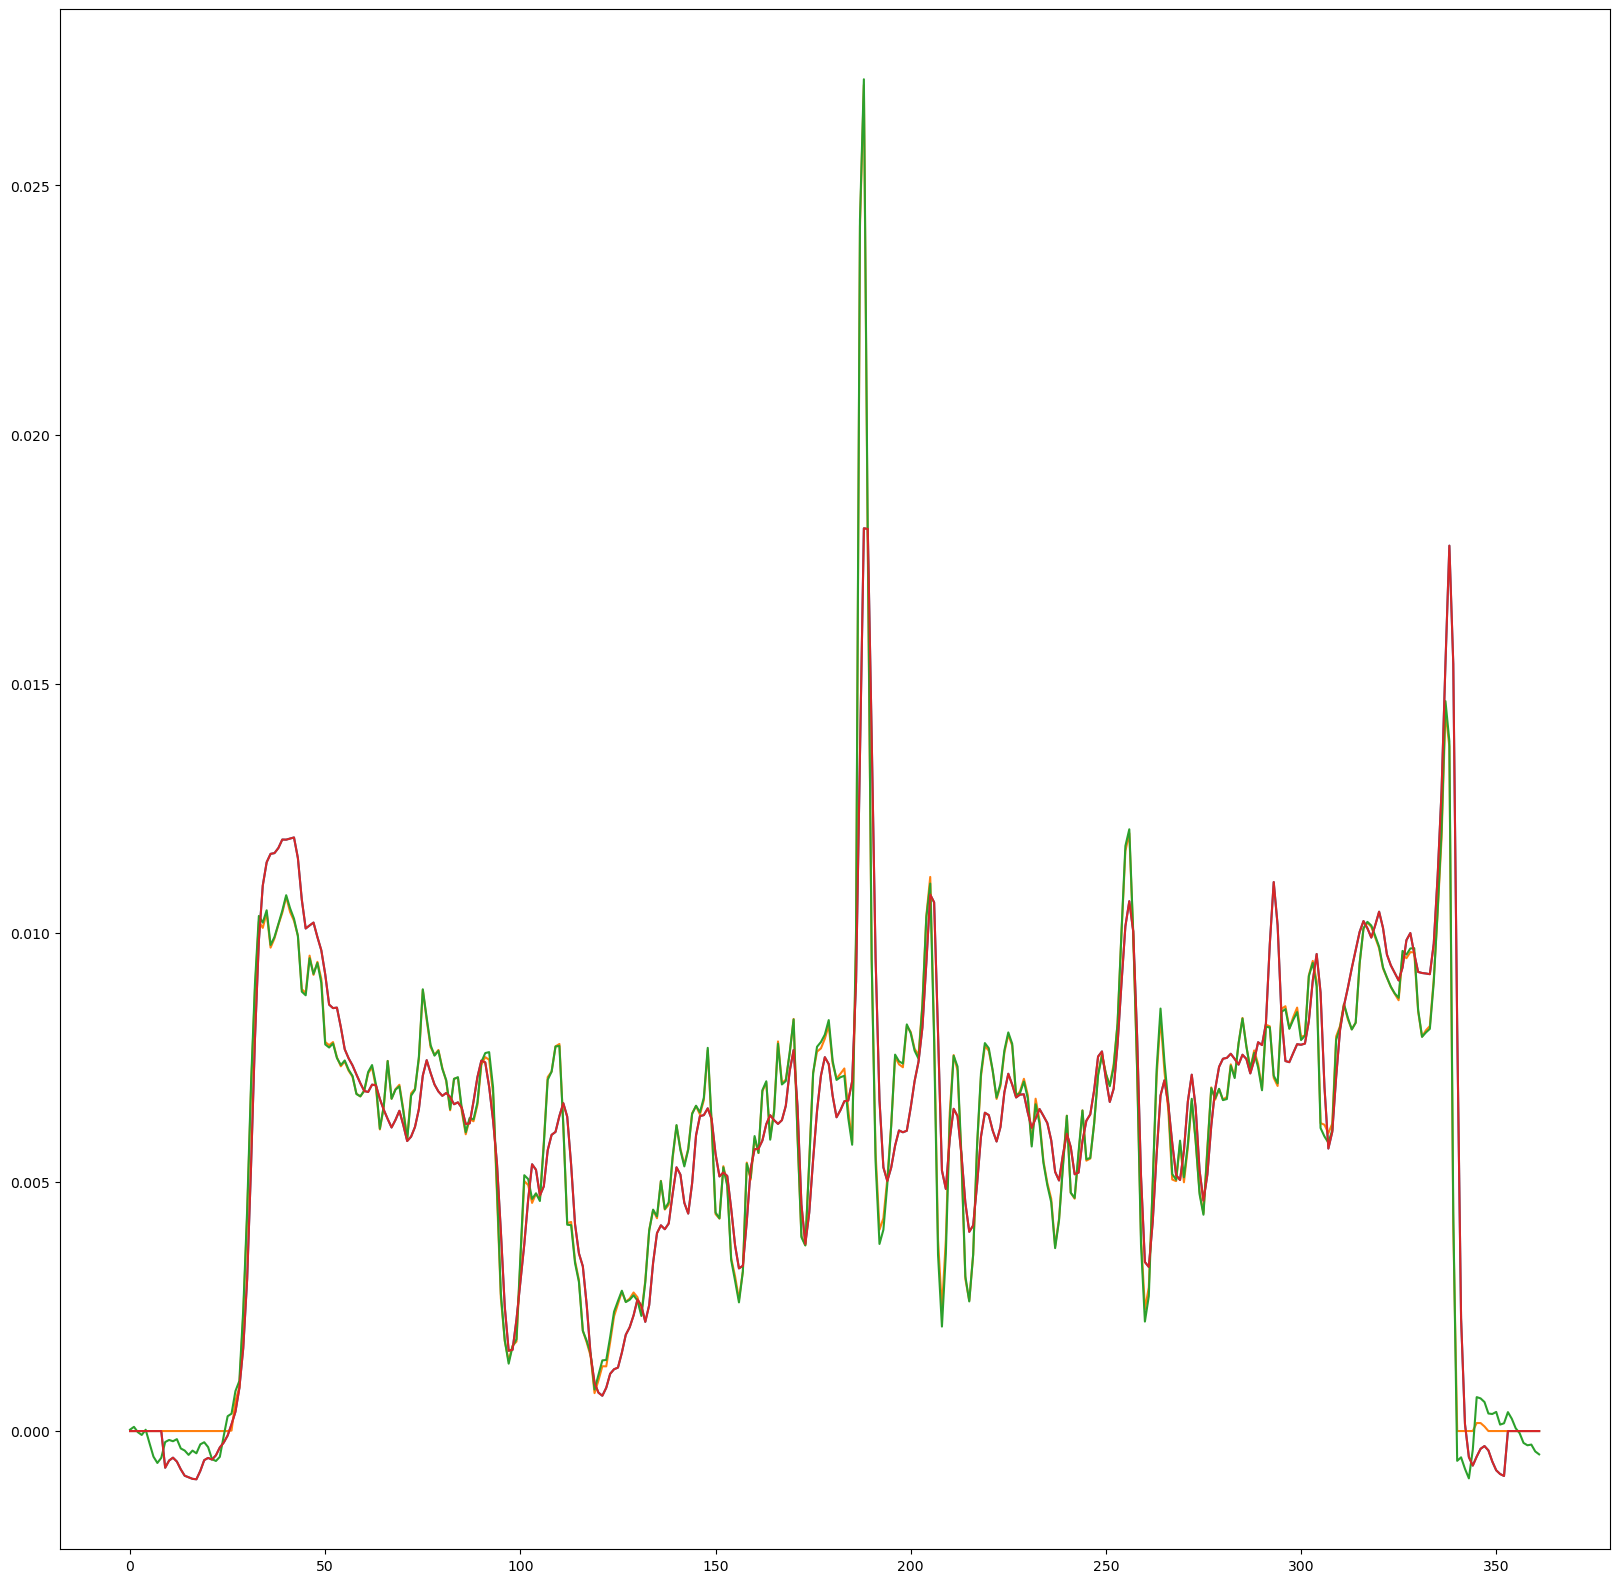

In [66]:
plt.figure(figsize=(20,20))
plt.plot(recon_cgls[-2][0,60,:])
plt.plot(recon_cgls[-1][0,60,:])
plt.plot(recon_cgls[0][0,60,:])
plt.plot(recon_cgls[1][0,60,:])
plt.show()

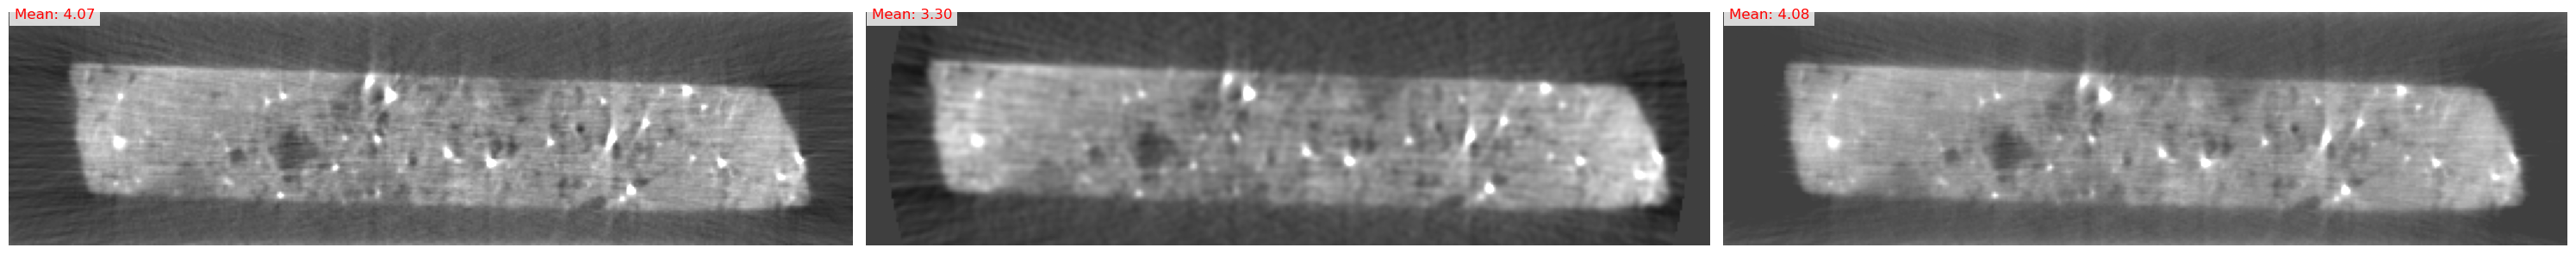

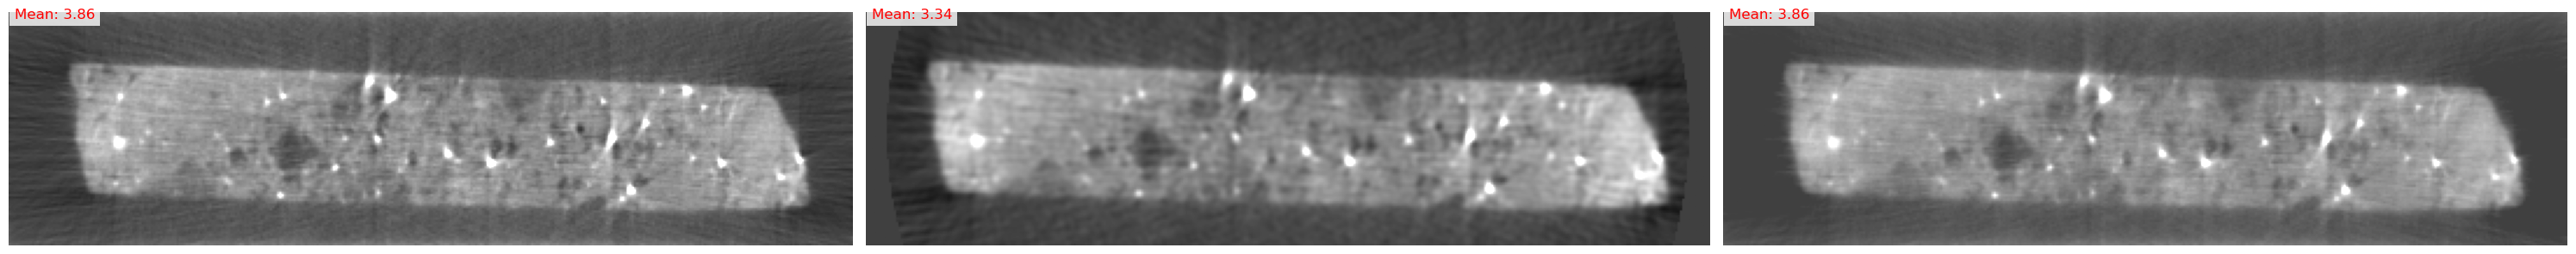

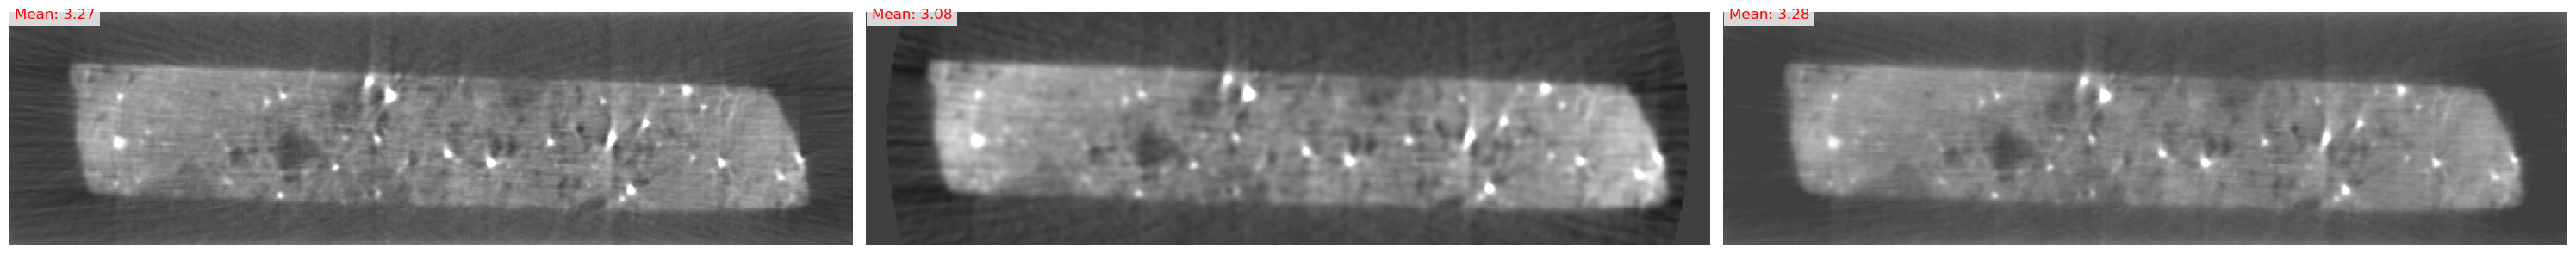

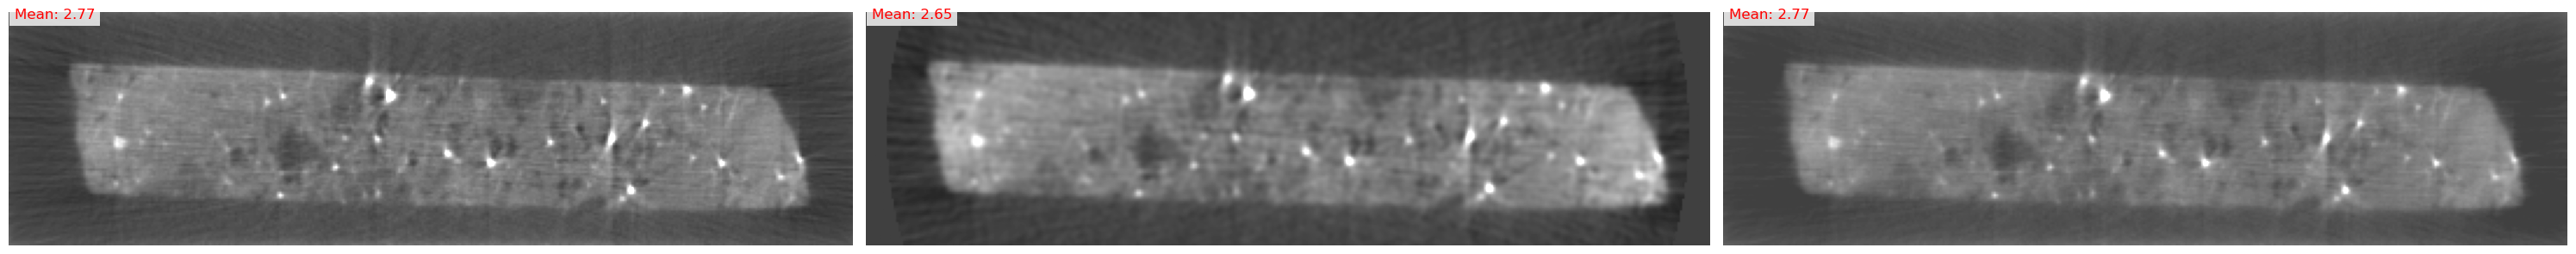

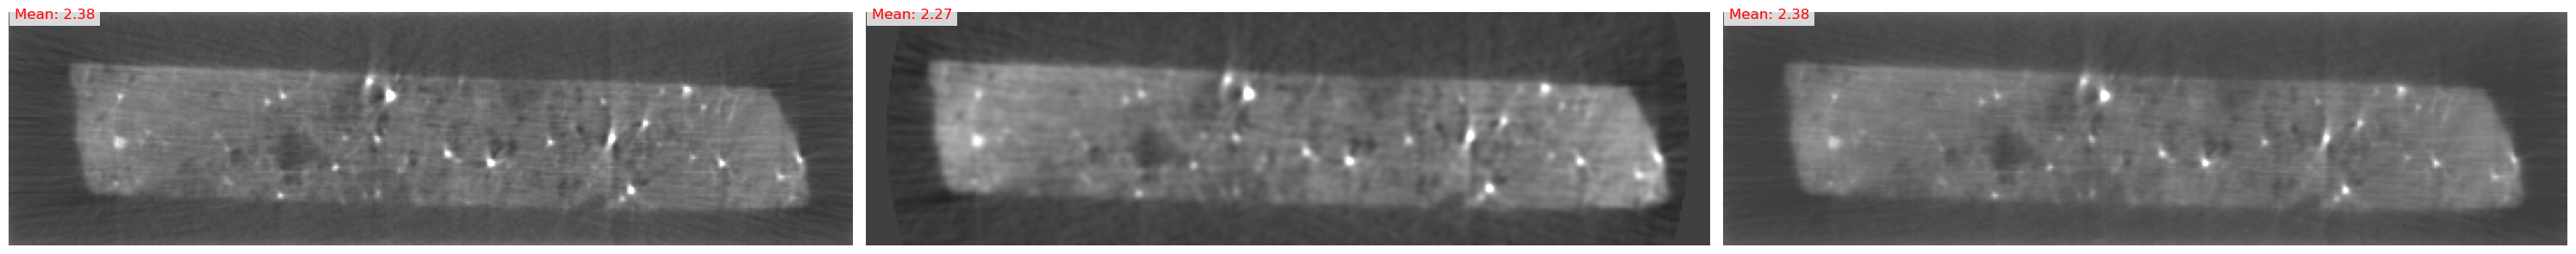

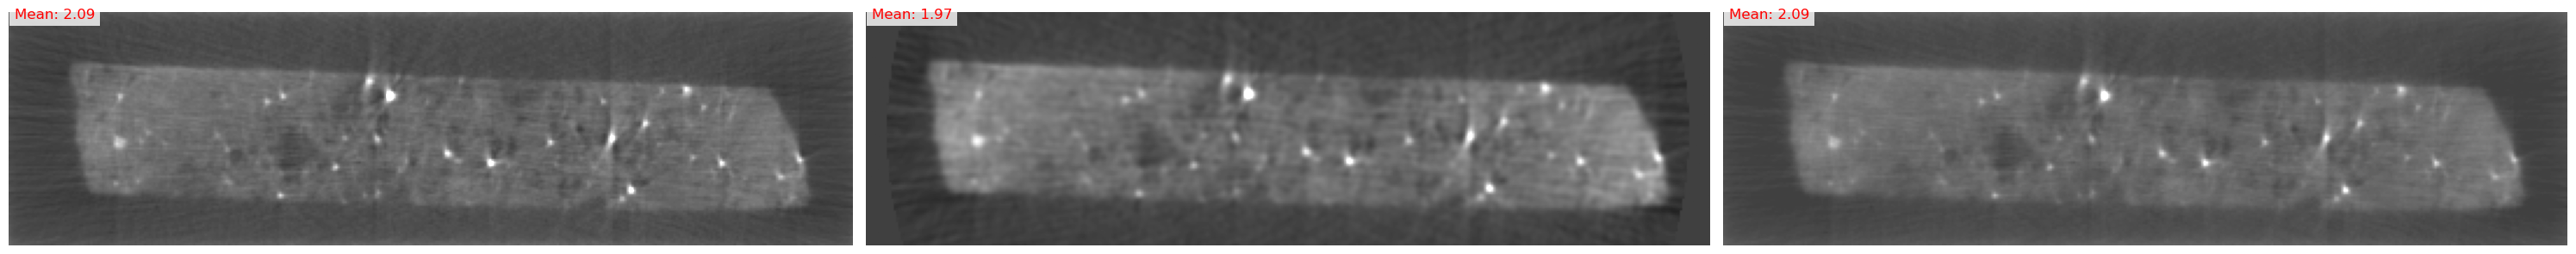

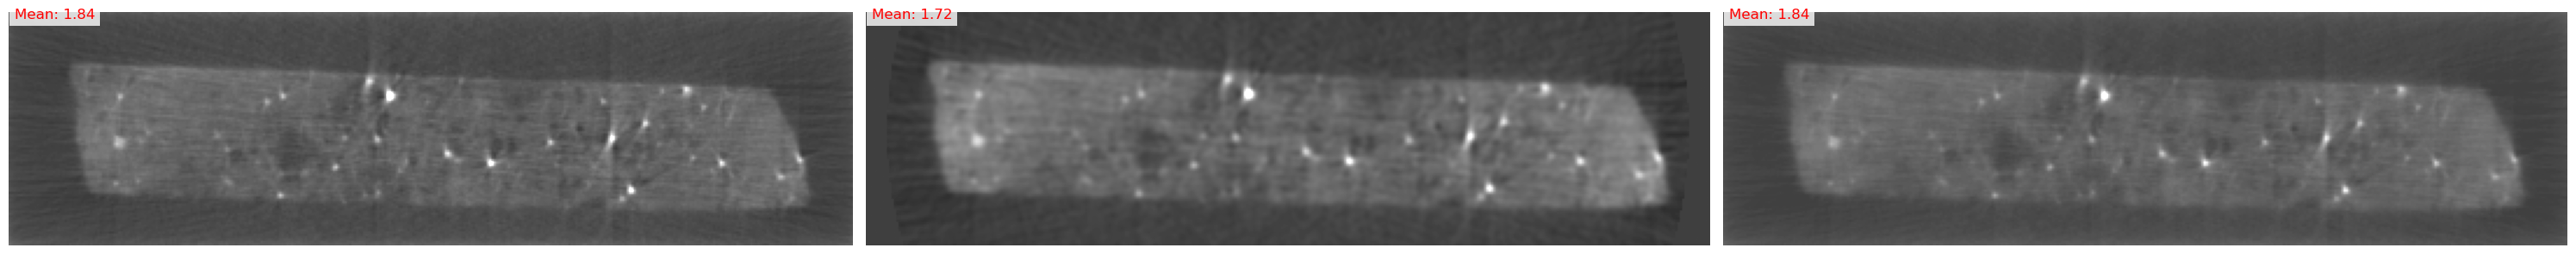

In [30]:
for i in np.arange(0,(c1-c0)//3,(c1-c0)//3//6):
    # Create a figure with multiple subplots
    fig, axes = plt.subplots(1, 3, figsize=(30, 10))

    for j in range(3):
        ax = axes[j]
        if j==1:
            i = 3*i
        if j==2:
            i=i//3
        mean_value = np.mean(recon_cgls[j][i])*1000
        ax.imshow(recon_cgls[j][i], cmap='gray', vmin=-0.005,vmax=0.015)  # Display the i-th image from array j
        ax.axis('off')  # Hide axes
        # Overlay the mean value as text in the top-left corner
        ax.text(
            2, 2, f"Mean: {mean_value:.2f}", color='red', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )

    plt.tight_layout()
    plt.show()

In [43]:
plt.figure(figsize=(20,20))
for i in range(len(alpha_dc_array)):
    plt.plot(recon_cgls[i][:,60,150])
    plt.plot(recon_cgls[i][:,40,150])
    plt.plot(recon_cgls[i][:,60,200])
#plt.ylim([-0.01,0.02])
plt.title('Direct')
plt.savefig('/dtu-compute/msaca/cache/plot1.png')
plt.close('all')

In [45]:
plt.figure(figsize=(20,20))
plt.imshow(recon_cgls[0][10])
plt.clim([-0.01,0.02])
plt.colorbar(orientation='horizontal')
plt.title('Direct')
plt.savefig('/dtu-compute/msaca/cache/plot2.png')
plt.close('all')

In [18]:
fdx = FiniteDifferenceOperator(ig, direction='horizontal_x', bnd_cond='Neumann')
fdy = FiniteDifferenceOperator(ig, direction='horizontal_y', bnd_cond='Neumann')
#fdc = FiniteDifferenceOperator(ig, direction='channel', bnd_cond='Neumann')

# Construct the BlockOperator combining the two operators
N = 20
alpha_id = 2/N
alpha_dx = 1/N
alpha_dy = 3/N
L = alpha_id*IdentityOperator(ig)
A = ProjectionOperator(ig, ag, 'gpu')
FD = alpha*BlockOperator(alpha_dx * fdx,alpha_dy *  fdy)
A_block = BlockOperator(L,FD, A)

g_block = BlockDataContainer(L.range.allocate(0), FD.range.allocate(0), data_)

constraint = IndicatorBox(lower=-0.00)
# set up and run CGLS
optimizer = SIRT(operator=A_block, data=g_block, constraint = constraint)
optimizer.run(150)
recon_sirt = optimizer.solution.as_array().astype(np.float32)

/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/cil/framework/data_container.py:410: RuntimeWarning: divide by zero encountered in power
  out = pwop(self.as_array() , x2 , *args, **kwargs )


  0%|          | 0/150 [00:00<?, ?it/s]

In [20]:
plt.figure(figsize=(20,20))
plt.imshow(recon_sirt[0])
#plt.clim([-0.01,0.02])
plt.colorbar(orientation='horizontal')
plt.title('Direct')
plt.savefig('/dtu-compute/msaca/cache/plot.png')
plt.close('all')

In [ ]:
initial = ig.allocate(0)


L = IdentityOperator(ig)
alpha = 30
A = ProjectionOperator(ig, ag, 'gpu')
operator_block = BlockOperator(A, alpha*L)
zero_data = L.range.allocate(0)
data_block = BlockDataContainer(data_, zero_data)



F = 0.5 * L2NormSquared(b=data_)
alpha = 10000000
G = alpha * L2NormSquared()

# Define BlockFunction F
f1 = alpha* MixedL21Norm()
f2 = 0.5 * L2NormSquared(b=data_)
F = BlockFunction(f1, f2)

# Define BlockOperator K
Grad = GradientOperator(ig)
K = BlockOperator(Grad, A)

# Define Function G
G = IndicatorBox(lower=-10)

optimizer = PDHG(f=F, g=G, operator=K)
optimizer.run(10, verbose=1)
recon = optimizer.solution.as_array().astype(np.float32)

In [ ]:
# Create Projection Operator
A = ProjectionOperator(ig, ag, 'gpu')
# Set up operators for BlockOperator
Grad = GradientOperator(ig, correlation="Space", backend='numpy')

alpha = 10
A_block = BlockOperator(alpha*Grad, A)
g_block = BlockDataContainer(Grad.domain.allocate(0), data_)

#set up and run CGLS
optimizer = CGLS(operator=A_block, data=g_block, update_objective_interval=2)


optimizer.run(30, verbose=1)
recon = optimizer.solution.as_array().astype(np.float32)

In [ ]:
# Create Projection Operator
A = ProjectionOperator(ig, ag, 'gpu')
# Set up operators for BlockOperator
Grad = GradientOperator(ig, correlation="SpaceChannels", split=True)


K= BlockOperator(Grad, A)



# Define regularising parameter alpha
alpha = 0.003
beta = 0.5

f1 = BlockFunction(beta*L1Norm(), alpha * MixedL21Norm())
f2 = 0.5 * L2NormSquared(b=data_)

F = BlockFunction(f1, f2)
G = IndicatorBox(lower=-0.01)

# Compute the operator norm for K
normK = K.norm()
# Define the step sizes sigma and tau
sigma = 1./normK
tau = 1./normK



optimizer = PDHG(f=F, g=G, operator=K, tau=tau, sigma=sigma, update_objective_interval=25)
optimizer.run(10, verbose=1)
recon = optimizer.solution.as_array().astype(np.float32)